In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stat
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
import sklearn.metrics as metrics
from sklearn import feature_selection as fs
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import matplotlib.ticker as ticker

In [2]:
Pima = pd.read_csv('Pima Indians Diabetes\diabetes.csv')

In [7]:
PimaMedian = Pima.copy(deep=True)
PimaMean = Pima.copy(deep=True)

In [4]:
change = ['BloodPressure','SkinThickness','Insulin','BMI','Glucose']
PimaMedian[change] = Pima[change].replace(0,Pima[change].median())
PimaMedian[PimaMedian["BloodPressure"]==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [8]:
PimaMean[change] = Pima[change].replace(0,Pima[change].mean())
PimaMean[PimaMean["BloodPressure"]==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [10]:
PimaMean

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0
764,2,122.0,70.0,27.000000,79.799479,36.8,0.340,27,0
765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0
766,1,126.0,60.0,20.536458,79.799479,30.1,0.349,47,1


In [5]:
names = list(PimaMedian.columns)[:-1]

for name in names:
    PimaMedian[f'{name}'] = stat.zscore(PimaMedian[f'{name}'])

In [6]:
Data_median = PimaMedian.drop(columns='Outcome').values
target_median = PimaMedian['Outcome']

In [8]:
Pima_drop_var_median = pd.DataFrame(Data_median,columns = names)
Pima_drop_var_median = Pima_drop_var_median.drop(columns = ['SkinThickness','Insulin'],axis=1).values

In [9]:
median_drop_train_data,median_drop_test_data,median_drop_train_target,median_drop_test_target = train_test_split(Pima_drop_var_median,
                                                                      target_median,
                                                                      test_size=0.2,
                                                                      random_state=999,
                                                                      stratify = target_median)

In [12]:
KNN_classifier = KNeighborsClassifier(p=1, n_neighbors=5)
LR_classifier = LogisticRegression(penalty='l2',C=1/5)
DT_classifier = DecisionTreeClassifier(max_depth=4,min_samples_split=2,criterion='gini')
RF_classifier = RandomForestClassifier(max_depth=8,min_samples_split=2,criterion='gini')
SVM_classifier = SVC(C=1/5,degree=1,kernel='poly')

In [73]:
KNN_classifier.fit(median_drop_train_data,median_drop_train_target)

KNeighborsClassifier(p=1)

In [79]:
KNN_result = KNN_classifier.predict(median_drop_test_data)

In [74]:
LR_classifier.fit(median_drop_train_data,median_drop_train_target)

LogisticRegression(C=0.2)

In [80]:
LR_result = LR_classifier.predict(median_drop_test_data)

In [75]:
DT_classifier.fit(median_drop_train_data,median_drop_train_target)

DecisionTreeClassifier(max_depth=4)

In [81]:
DT_result = DT_classifier.predict(median_drop_test_data)

In [76]:
RF_classifier.fit(median_drop_train_data,median_drop_train_target)

RandomForestClassifier(max_depth=8)

In [82]:
RF_result = RF_classifier.predict(median_drop_test_data)

In [77]:
SVM_classifier.fit(median_drop_train_data,median_drop_train_target)

SVC(C=0.2, degree=1, kernel='poly')

In [83]:
SVM_result = SVM_classifier.predict(median_drop_test_data)

In [14]:
def metric(predicted):
    accuracy = metrics.accuracy_score(median_drop_test_target,predicted)
    precision = metrics.precision_score(median_drop_test_target,predicted)
    recall = metrics.recall_score(median_drop_test_target,predicted)
    f1 = metrics.f1_score(median_drop_test_target,predicted)
    return [accuracy,precision,recall,f1]

In [95]:
e=metric(KNN_result)

In [89]:
a=metric(LR_result)

In [90]:
b=metric(DT_result)

In [91]:
c=metric(RF_result)

In [92]:
d=metric(SVM_result)

In [193]:
acc = [a[0],b[0],c[0],d[0],e[0]]
prec = [a[1],b[1],c[1],d[1],e[1]]
rec = [a[2],b[2],c[2],d[2],e[2]]
f1 = [a[3],b[3],c[3],d[3],e[3]]

In [194]:
acc


[0.7987012987012987,
 0.7467532467532467,
 0.7662337662337663,
 0.7987012987012987,
 0.7142857142857143]

Text(0.5, 1.0, 'Accuracy score for each algorithm')

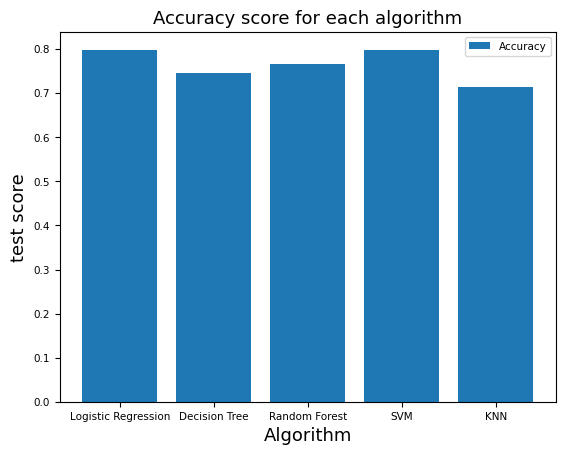

In [195]:
plt.bar(['Logistic Regression','Decision Tree','Random Forest','SVM','KNN'],acc,label = 'Accuracy')
plt.legend()
plt.rcParams.update({'font.size':7.5})
plt.xlabel('Algorithm',fontsize = 13)
plt.ylabel('test score',fontsize=13)
plt.title('Accuracy score for each algorithm',fontsize=13)

Text(0.5, 1.0, 'Accuracy score for each algorithm')

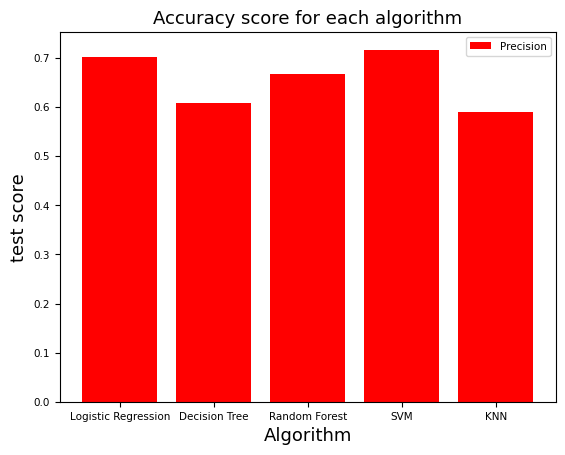

In [196]:
plt.bar(['Logistic Regression','Decision Tree','Random Forest','SVM','KNN'],prec,label = 'Precision',color='red')
plt.legend()
plt.rcParams.update({'font.size':7.5})
plt.xlabel('Algorithm',fontsize = 13)
plt.ylabel('test score',fontsize=13)
plt.title('Accuracy score for each algorithm',fontsize=13)

Text(0.5, 1.0, 'Recall score for each algorithm')

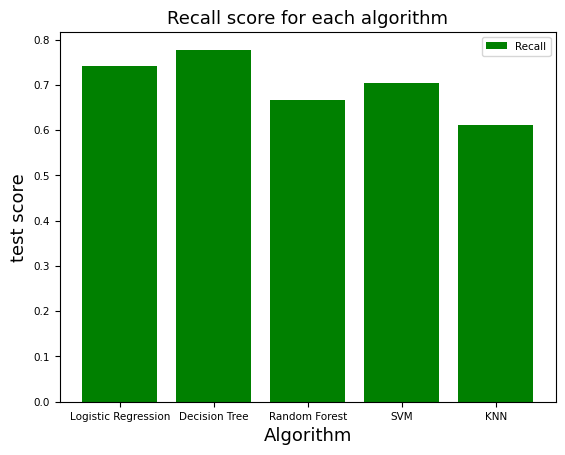

In [197]:
plt.bar(['Logistic Regression','Decision Tree','Random Forest','SVM','KNN'],rec,label = 'Recall',color='green')
plt.legend()
plt.rcParams.update({'font.size':7.5})
plt.xlabel('Algorithm',fontsize = 13)
plt.ylabel('test score',fontsize=13)
plt.title('Recall score for each algorithm',fontsize=13)

Text(0.5, 1.0, 'F1 score for each algorithm')

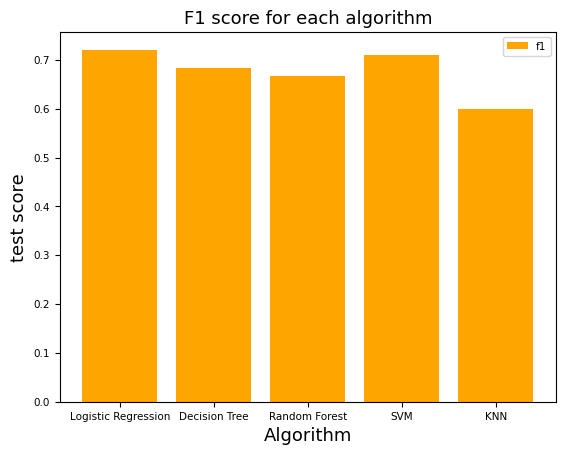

In [198]:
plt.bar(['Logistic Regression','Decision Tree','Random Forest','SVM','KNN'],f1,label = 'f1',color='orange')
plt.legend()
plt.rcParams.update({'font.size':7.5})
plt.xlabel('Algorithm',fontsize = 13)
plt.ylabel('test score',fontsize=13)
plt.title('F1 score for each algorithm',fontsize=13)

In [199]:
data = {'Model':['Logistic Regression','Decision Tree','Random Forest','SVM','KNN'],
        'Accuracy':acc,
       'Precision':prec,
       'Recall':rec,
       'f1':f1}

In [200]:
results = pd.DataFrame(data)

In [201]:
results.set_index('Model',inplace = True)

In [202]:
results

,Accuracy,Precision,Recall,f1
Model,,,,
Logistic Regression,0.798701,0.701754,0.740741,0.720721
Decision Tree,0.746753,0.608696,0.777778,0.682927
Random Forest,0.766234,0.666667,0.666667,0.666667
SVM,0.798701,0.716981,0.703704,0.710280
KNN,0.714286,0.589286,0.611111,0.600000


# Model 1b

In [11]:
names = list(PimaMean.columns)[:-1]

for name in names:
    PimaMean[f'{name}'] = stat.zscore(PimaMean[f'{name}'])

In [12]:
Data_mean = PimaMean.drop(columns='Outcome').values
target_mean = PimaMean['Outcome']

In [13]:
Pima_drop_var_mean = pd.DataFrame(Data_mean,columns = names)
Pima_drop_var_mean = Pima_drop_var_mean.drop(columns = ['SkinThickness','Insulin'],axis=1).values

In [15]:
mean_drop_train_data,mean_drop_test_data,mean_drop_train_target,mean_drop_test_target = train_test_split(Pima_drop_var_mean,
                                                                      target_median,
                                                                      test_size=0.2,
                                                                      random_state=999,
                                                                      stratify = target_median)

In [16]:
KNN_classifier2 = KNeighborsClassifier(p=2, n_neighbors=5)
LR_classifier2 = LogisticRegression(penalty=None)
DT_classifier2 = DecisionTreeClassifier(max_depth=4,min_samples_split=3,criterion='gini')
RF_classifier2 = RandomForestClassifier(max_depth=8,min_samples_split=2,criterion='gini')
SVM_classifier2 = SVC(C=1/5,degree=1,kernel='poly')

# Model 2

In [17]:
KNN_classifier3 = KNeighborsClassifier(p=2, n_neighbors=5)
LR_classifier3 = LogisticRegression(penalty=None)
DT_classifier3 = DecisionTreeClassifier(max_depth=4,min_samples_split=2,criterion='gini')
RF_classifier3 = RandomForestClassifier(max_depth=8,min_samples_split=2,criterion='gini')
SVM_classifier3 = SVC(C=1/5,degree=1,kernel='poly')

# Model 3

In [ ]:
KNN_classifier4 = KNeighborsClassifier(p=2, n_neighbors=5)
LR_classifier4 = LogisticRegression(penalty=None)
DT_classifier4 = DecisionTreeClassifier(max_depth=4,min_samples_split=2,criterion='gini')
RF_classifier4 = RandomForestClassifier(max_depth=8,min_samples_split=2,criterion='gini')
SVM_classifier4 = SVC(C=1/5,degree=1,kernel='poly')